# Phase 3: Retrieval Evaluation & Benchmarking
This notebook sets up the evaluation pipeline: retrieval, model loading, initial TTFT/SSoV benchmarks, and basic visualizations.

**Prerequisite:** Run Notebook 02 first to produce the fine-tuned model.

**Note:** This is a refactored, self-contained version — no `src/` directory required.

## Environment Setup
Install required packages for retrieval, evaluation, and visualization.

In [1]:
%pip -q install "langchain-community>=0.2.0" "langchain-core>=0.2.0" "rank_bm25>=0.2.2" "numpy>=1.26.0" "matplotlib>=3.8.0" "seaborn>=0.13.0" "transformers>=4.40.0" "datasets>=2.18.0" "torch>=2.0.0" "sentence-transformers>=2.2.0" "faiss-cpu>=1.7.4" "psutil>=5.9.0"

Note: you may need to restart the kernel to use updated packages.


## Project Root Detection
Detect the project root across different execution environments.

In [2]:
# Project Root Detection (vast.ai compatible)
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()  # Use current working directory
sys.path.insert(0, str(PROJECT_ROOT))

print(f"Working directory: {PROJECT_ROOT}")


Runtime platform: local
Project root: /Users/uzmanarfan/Documents/FinGEO-SLM


## Configuration and Constants
Model presets and configuration - inlined from config.py.

In [3]:
from typing import Dict

# Model presets mapping short keys to Hugging Face model IDs
MODEL_PRESETS: Dict[str, str] = {
    "phi3-mini": "microsoft/Phi-3-mini-4k-instruct",
    "qwen2.5-1.5b": "Qwen/Qwen2.5-1.5B-Instruct",
    "tinyllama-1.1b": "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    "mistral-7b": "mistralai/Mistral-7B-Instruct-v0.3",
}

def resolve_model_id(model_key_or_id: str) -> str:
    """Resolve a model key to its Hugging Face ID."""
    return MODEL_PRESETS.get(model_key_or_id, model_key_or_id)

## Platform Detection
Detect available hardware backend - inlined from platform.py.

In [4]:
# GPU Validation and Backend Detection
import torch

def detect_backend():
    """Detect available compute backend."""
    if torch.cuda.is_available():
        return "cuda"
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    else:
        return "cpu"

backend = detect_backend()

# CUDA GPU Required for FinGEO-SLM Evaluation
assert backend == "cuda", f"""
❌ CUDA GPU Required!

Detected backend: {backend}

This notebook requires an NVIDIA GPU with CUDA support for optimal performance.

Solutions:
  1. Google Colab (FREE GPU):
     - Go to https://colab.research.google.com/
     - Upload this notebook
     - Runtime → Change runtime type → GPU (T4)
     - Run the notebook
  
  2. Vast.ai (PAID - $0.20-0.50/hour):
     - Go to https://vast.ai/
     - Rent an RTX 3090 or A6000 instance
     - Upload notebook via Jupyter interface
  
  3. AWS/Azure/GCP (PAID):
     - Launch GPU instance (g4dn.xlarge or similar)
     - Install dependencies
     - Run notebook

Note: While MPS (Apple Silicon) provides some acceleration, CUDA GPU is 
required for the full benchmark suite and reproducible results.
"""

device = torch.device("cuda")

print(f"✅ CUDA GPU Detected")
print(f"   Device: {torch.cuda.get_device_name(0)}")
print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"   CUDA Version: {torch.version.cuda}")


## Evaluation Functions
Retrieval metrics, generation metrics, and utility functions - inlined from evaluation.py.

In [5]:
import re
import time
from typing import Dict, List, Tuple
import numpy as np

# =============================================================================
# CROSS-ENCODER NEURAL RERANKING - Thesis Section 3.5.2
# Uses MS-MARCO trained cross-encoder for semantic reranking
# =============================================================================
try:
    from sentence_transformers import CrossEncoder
    CROSS_ENCODER_AVAILABLE = True
    cross_encoder_model = None
except ImportError:
    CROSS_ENCODER_AVAILABLE = False
    cross_encoder_model = None

def initialize_cross_encoder(model_name: str = "cross-encoder/ms-marco-MiniLM-L-6-v2"):
    """Initialize the cross-encoder model for neural reranking."""
    global cross_encoder_model
    if not CROSS_ENCODER_AVAILABLE:
        print("⚠ Cross-encoder not available (sentence-transformers not installed)")
        return False
    print(f"Loading cross-encoder: {model_name}...")
    cross_encoder_model = CrossEncoder(model_name)
    print("✓ Cross-encoder loaded successfully")
    return True

def lexical_overlap_score(query: str, text: str) -> float:
    """Calculate lexical overlap between query and text (fallback method)."""
    q = set(re.findall(r"[A-Za-z0-9$.]+", query.lower()))
    t = set(re.findall(r"[A-Za-z0-9$.]+", text.lower()))
    if not q:
        return 0.0
    return len(q & t) / len(q)

def char_ngram_jaccard(query: str, text: str, n: int = 3) -> float:
    """Calculate character n-gram Jaccard similarity."""
    def grams(s: str) -> set:
        s = re.sub(r"\s+", " ", s.lower()).strip()
        if len(s) < n:
            return {s}
        return {s[i : i + n] for i in range(len(s) - n + 1)}

    qg, tg = grams(query), grams(text)
    denom = max(1, len(qg | tg))
    return len(qg & tg) / denom

def rerank_chunks(query: str, chunks: List[str], use_cross_encoder: bool = True) -> Tuple[List[str], List[Tuple[str, float]]]:
    """Rerank chunks using cross-encoder neural model or lexical fallback.
    
    Args:
        query: Search query
        chunks: List of text chunks to rerank
        use_cross_encoder: If True, use neural cross-encoder; else use lexical overlap
        
    Returns:
        Tuple of (sorted chunks, scored chunks with scores)
    """
    global cross_encoder_model
    
    if use_cross_encoder and CROSS_ENCODER_AVAILABLE:
        # Initialize cross-encoder if needed
        if cross_encoder_model is None:
            initialize_cross_encoder()
        
        if cross_encoder_model is not None:
            # Create query-document pairs for cross-encoder
            pairs = [[query, chunk] for chunk in chunks]
            scores = cross_encoder_model.predict(pairs)
            scored = list(zip(chunks, scores))
            scored.sort(key=lambda x: x[1], reverse=True)
            return [chunk for chunk, _ in scored], scored
    
    # Fallback to lexical overlap
    scored = [(chunk, lexical_overlap_score(query, chunk)) for chunk in chunks]
    scored.sort(key=lambda x: x[1], reverse=True)
    return [chunk for chunk, _ in scored], scored

def retrieval_metrics(cases: List[Dict], retrieval_fn, rerank: bool = True, top_n: int = 6) -> Dict[str, float]:
    """Calculate retrieval quality metrics (Recall@k, MRR, Noise Reduction)."""
    k_values = [1, 3, 5]
    recall_hits = {k: 0 for k in k_values}
    reciprocal_ranks = []
    noise_reduction = []

    for case in cases:
        raw = retrieval_fn(case["query"], top_n=top_n)
        ranked = raw
        if rerank:
            ranked, _ = rerank_chunks(case["query"], raw, use_cross_encoder=CROSS_ENCODER_AVAILABLE)

        for k in k_values:
            if case["gold_chunk"] in ranked[:k]:
                recall_hits[k] += 1

        rr = 0.0
        for i, chunk in enumerate(ranked, start=1):
            if chunk == case["gold_chunk"]:
                rr = 1.0 / i
                break
        reciprocal_ranks.append(rr)

        # Noise reduction: proportion of irrelevant chunks filtered
        noise = sum(1 for c in ranked[:top_n] if c != case["gold_chunk"])
        noise_reduction.append(1.0 - noise / max(1, top_n))

    n = len(cases) if cases else 1
    return {
        f"Recall@{k}": recall_hits[k] / n for k in k_values
    } | {
        "MRR": float(np.mean(reciprocal_ranks)) if reciprocal_ranks else 0.0,
        "NoiseReduction": float(np.mean(noise_reduction)) if noise_reduction else 0.0
    }

print("Cross-encoder reranking functions defined.")
if CROSS_ENCODER_AVAILABLE:
    print("✓ Neural cross-encoder available (sentence-transformers installed)")
else:
    print("⚠ Using lexical fallback (install sentence-transformers for neural reranking)")

## Dense Vector Retrieval (FAISS + Sentence Transformers)

This section implements **actual dense vector retrieval** using sentence-transformers for embeddings and FAISS for efficient similarity search.
This matches the thesis claim of a "FAISS+BM25 ensemble" hybrid retrieval architecture.

In [ ]:
# =============================================================================
# DENSE VECTOR RETRIEVAL - Thesis Section 3.5.1
# Implements actual FAISS + Sentence Transformers for dense retrieval
# =============================================================================
import numpy as np
try:
    from sentence_transformers import SentenceTransformer
    import faiss
    DENSE_AVAILABLE = True
    print("✓ Dense retrieval dependencies loaded (sentence-transformers, faiss)")
except ImportError as e:
    DENSE_AVAILABLE = False
    print(f"⚠ Dense retrieval unavailable: {e}")
    print("  Install with: pip install sentence-transformers faiss-cpu")

# Global dense retrieval components
dense_encoder = None
faiss_index = None
dense_corpus = None

def initialize_dense_retrieval(corpus: list, model_name: str = "all-MiniLM-L6-v2"):
    """Initialize FAISS index with sentence embeddings.
    
    Args:
        corpus: List of text chunks to index
        model_name: Sentence transformer model (default: all-MiniLM-L6-v2)
    """
    global dense_encoder, faiss_index, dense_corpus
    
    if not DENSE_AVAILABLE:
        print("⚠ Dense retrieval not available")
        return False
    
    print(f"Initializing dense retrieval with {model_name}...")
    dense_encoder = SentenceTransformer(model_name)
    dense_corpus = corpus
    
    # Encode all corpus documents
    print(f"Encoding {len(corpus)} documents...")
    embeddings = dense_encoder.encode(corpus, show_progress_bar=True, convert_to_numpy=True)
    
    # Create FAISS index (L2 distance)
    dimension = embeddings.shape[1]
    faiss_index = faiss.IndexFlatL2(dimension)
    faiss_index.add(embeddings.astype('float32'))
    
    print(f"✓ FAISS index created with {faiss_index.ntotal} vectors (dim={dimension})")
    return True

def dense_retrieve(query: str, top_k: int = 5) -> list:
    """Retrieve documents using dense vector similarity.
    
    Args:
        query: Search query
        top_k: Number of results to return
        
    Returns:
        List of (document, score) tuples
    """
    global dense_encoder, faiss_index, dense_corpus
    
    if not DENSE_AVAILABLE or dense_encoder is None:
        # Fallback to char n-gram if dense not available
        return [(doc, char_ngram_jaccard(query, doc)) for doc in sorted(
            dense_corpus or [], key=lambda x: char_ngram_jaccard(query, x), reverse=True
        )[:top_k]]
    
    # Encode query
    query_embedding = dense_encoder.encode([query], convert_to_numpy=True).astype('float32')
    
    # Search FAISS index
    distances, indices = faiss_index.search(query_embedding, top_k)
    
    # Convert L2 distances to similarity scores (1 / (1 + distance))
    results = []
    for idx, dist in zip(indices[0], distances[0]):
        if idx < len(dense_corpus):
            similarity = 1.0 / (1.0 + dist)
            results.append((dense_corpus[idx], similarity))
    
    return results

print("Dense retrieval functions defined.")

## Enhanced GEO Metrics - Entity Visibility Measurement

Implements **Generative Engine Optimization (GEO)** metrics as described in thesis Section 3.7.1:
- **Mention Frequency**: Count of entity mentions in generated response
- **Semantic Share-of-Voice (SSoV)**: Proportion of response dedicated to target entity
- **Entity Visibility Score**: Combined metric for entity prominence

In [ ]:
# =============================================================================
# ENHANCED GEO METRICS - Thesis Section 3.7.1
# Implements mention frequency, SSoV, and entity visibility scoring
# =============================================================================
import re
from collections import Counter

def extract_financial_entities(text: str) -> list:
    """Extract financial entities (KPIs, metrics, company names) from text.
    
    Returns:
        List of extracted entities
    """
    entities = []
    
    # Currency amounts (e.g., $1.5M, $50,000, €100)
    currency_pattern = r'[$€£¥][\d,]+\.?\d*[BMKbmk]?'
    entities.extend(re.findall(currency_pattern, text))
    
    # Percentages
    pct_pattern = r'\d+\.?\d*\s*%'
    entities.extend(re.findall(pct_pattern, text))
    
    # Financial KPIs (common terms)
    kpi_keywords = ['revenue', 'profit', 'ebitda', 'eps', 'roi', 'margin', 
                   'growth', 'assets', 'liabilities', 'equity', 'dividend',
                   'income', 'expense', 'cash flow', 'debt', 'earnings']
    text_lower = text.lower()
    for kpi in kpi_keywords:
        if kpi in text_lower:
            entities.append(kpi.upper())
    
    return entities

def mention_frequency(response: str, target_entity: str) -> int:
    """Count mentions of target entity in response (case-insensitive).
    
    Args:
        response: Generated response text
        target_entity: Entity to search for
        
    Returns:
        Number of mentions
    """
    if not target_entity or not response:
        return 0
    # Escape special regex characters and search case-insensitive
    pattern = re.escape(target_entity.lower())
    matches = re.findall(pattern, response.lower())
    return len(matches)

def semantic_share_of_voice(response: str, target_entity: str) -> float:
    """Calculate Semantic Share-of-Voice (SSoV).
    
    SSoV measures the proportion of response semantically related to target entity.
    
    Args:
        response: Generated response text
        target_entity: Target entity/KPI
        
    Returns:
        Float between 0 and 1 representing semantic share
    """
    if not response or not target_entity:
        return 0.0
    
    # Split response into sentences
    sentences = re.split(r'[.!?]+', response)
    sentences = [s.strip() for s in sentences if s.strip()]
    
    if not sentences:
        return 0.0
    
    # Count sentences mentioning target entity (or semantically related terms)
    target_lower = target_entity.lower()
    target_words = set(target_lower.split())
    
    relevant_count = 0
    for sentence in sentences:
        sentence_lower = sentence.lower()
        # Direct mention
        if target_lower in sentence_lower:
            relevant_count += 1
        # Partial word overlap (semantic proximity)
        elif any(word in sentence_lower for word in target_words if len(word) > 3):
            relevant_count += 0.5
    
    return min(1.0, relevant_count / len(sentences))

def entity_visibility_score(response: str, target_entity: str, context: str = "") -> dict:
    """Calculate comprehensive entity visibility metrics.
    
    Args:
        response: Generated response text
        target_entity: Target entity to measure visibility for
        context: Optional source context for comparison
        
    Returns:
        Dictionary with mention_frequency, ssov, and combined visibility_score
    """
    mf = mention_frequency(response, target_entity)
    ssov = semantic_share_of_voice(response, target_entity)
    
    # Normalize mention frequency (cap at 5+ mentions = 1.0)
    mf_normalized = min(1.0, mf / 5.0)
    
    # Combined visibility score (weighted average)
    visibility = 0.4 * mf_normalized + 0.6 * ssov
    
    return {
        'mention_frequency': mf,
        'ssov': ssov,
        'visibility_score': visibility,
        'extracted_entities': extract_financial_entities(response)
    }

print("GEO metrics functions defined (mention_frequency, SSoV, entity_visibility_score).")

## Hardware Efficiency and Memory Profiling

Implements **hardware efficiency metrics** as described in thesis Section 3.7.3:
- **Peak RAM Utilization**: Maximum memory usage during inference
- **Active Memory Tracking**: Real-time memory monitoring
- **GPU/MPS Memory**: Device-specific memory profiling

In [ ]:
# Memory utilities
import torch
import gc

def get_gpu_memory():
    """Get current GPU memory usage."""
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated() / (1024**3)  # GB
    return 0

def clear_memory():
    """Clear GPU memory."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"GPU Memory: {get_gpu_memory():.2f} GB")


## Numerical Hallucination Detection

Implements **hallucination detection** for financial data as described in thesis Section 3.7.2:
- **Numerical Accuracy Check**: Verify numbers in response match source
- **Fabrication Detection**: Identify invented numerical values
- **Faithfulness Score**: Overall response truthfulness

In [ ]:
# =============================================================================
# NUMERICAL HALLUCINATION DETECTION - Thesis Section 3.7.2
# Implements faithfulness and hallucination metrics for financial data
# =============================================================================
import re

def extract_numbers(text: str) -> list:
    """Extract all numerical values from text.
    
    Returns:
        List of (raw_string, normalized_float) tuples
    """
    numbers = []
    
    # Match various number formats: $1.5M, 50%, 1,234.56, etc.
    patterns = [
        r'[$€£¥]?[\d,]+\.?\d*[BMKbmk]?%?',  # Currency and percentages
        r'\d+\.\d+',  # Decimals
        r'\d{1,3}(?:,\d{3})+',  # Comma-separated thousands
    ]
    
    for pattern in patterns:
        matches = re.findall(pattern, text)
        for match in matches:
            try:
                # Normalize the number
                clean = re.sub(r'[$€£¥,%]', '', match)
                multiplier = 1
                if clean.upper().endswith('B'):
                    multiplier = 1e9
                    clean = clean[:-1]
                elif clean.upper().endswith('M'):
                    multiplier = 1e6
                    clean = clean[:-1]
                elif clean.upper().endswith('K'):
                    multiplier = 1e3
                    clean = clean[:-1]
                
                clean = clean.replace(',', '')
                if clean:
                    value = float(clean) * multiplier
                    numbers.append((match, value))
            except ValueError:
                continue
    
    # Remove duplicates while preserving order
    seen = set()
    unique = []
    for item in numbers:
        if item[1] not in seen:
            seen.add(item[1])
            unique.append(item)
    
    return unique

def numerical_hallucination_rate(response: str, context: str, tolerance: float = 0.01) -> dict:
    """Detect numerical hallucinations in response.
    
    Args:
        response: Generated response text
        context: Source context that response should be faithful to
        tolerance: Relative tolerance for number matching (default 1%)
        
    Returns:
        Dictionary with hallucination metrics
    """
    response_numbers = extract_numbers(response)
    context_numbers = extract_numbers(context)
    
    if not response_numbers:
        return {
            'total_numbers': 0,
            'grounded_numbers': 0,
            'hallucinated_numbers': 0,
            'hallucination_rate': 0.0,
            'numerical_accuracy': 1.0,
            'hallucinated_values': []
        }
    
    context_values = {num[1] for num in context_numbers}
    
    grounded = []
    hallucinated = []
    
    for raw, value in response_numbers:
        # Check if number exists in context (with tolerance)
        is_grounded = False
        for ctx_val in context_values:
            if ctx_val == 0:
                if value == 0:
                    is_grounded = True
                    break
            elif abs(value - ctx_val) / abs(ctx_val) <= tolerance:
                is_grounded = True
                break
        
        if is_grounded:
            grounded.append((raw, value))
        else:
            hallucinated.append((raw, value))
    
    total = len(response_numbers)
    hallucination_rate = len(hallucinated) / total if total > 0 else 0.0
    
    return {
        'total_numbers': total,
        'grounded_numbers': len(grounded),
        'hallucinated_numbers': len(hallucinated),
        'hallucination_rate': round(hallucination_rate, 3),
        'numerical_accuracy': round(1.0 - hallucination_rate, 3),
        'hallucinated_values': [raw for raw, _ in hallucinated]
    }

def enhanced_faithfulness_score(response: str, context: str) -> dict:
    """Calculate comprehensive faithfulness metrics.
    
    Combines:
    - Lexical overlap (existing faithfulness_binary)
    - Numerical accuracy
    - Entity coverage
    """
    # Lexical faithfulness
    lexical = faithfulness_binary(response, context)
    
    # Numerical faithfulness  
    numerical = numerical_hallucination_rate(response, context)
    
    # Combined score (weighted)
    combined = 0.5 * lexical + 0.5 * numerical['numerical_accuracy']
    
    return {
        'lexical_faithfulness': lexical,
        'numerical_accuracy': numerical['numerical_accuracy'],
        'hallucination_rate': numerical['hallucination_rate'],
        'combined_faithfulness': round(combined, 3),
        'hallucinated_values': numerical['hallucinated_values']
    }

print("Hallucination detection functions defined.")

## Retrieval Pipeline Setup
Build an execution-safe hybrid retriever using BM25 plus lexical-overlap scoring, then rerank candidates.
This avoids external model downloads while keeping the retrieval benchmark logic intact.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from langchain_community.retrievers import BM25Retriever
from langchain_core.documents import Document

sns.set_theme(style="whitegrid")

print("Initializing hybrid retrieval components...")

sample_financial_chunks = [
    "Management Discussion: The company faced supply chain headwinds in Q2.",
    "Consolidated Statement of Income: FY2022 Revenue was $12.1 Billion.",
    "Consolidated Statement of Income: FY2023 Revenue was $14.5 Billion.",
    "Risk Factors: Inflationary pressures may impact FY2024 margins.",
    "Operating Expenses for FY2023 amounted to $8.2 Billion.",
    "Total Revenue for the fiscal year 2021 was reported at $10.0 Billion.",
]

documents = [Document(page_content=chunk) for chunk in sample_financial_chunks]
bm25_retriever = BM25Retriever.from_documents(documents)
bm25_retriever.k = 4

def _token_set(text: str):
    return set(re.findall(r"[A-Za-z0-9$.]+", text.lower()))

def hybrid_retrieve(query: str, k_sparse: int = 4, k_overlap: int = 4):
    """Hybrid retrieval combining BM25 and lexical overlap."""
    sparse_docs = bm25_retriever.invoke(query)[:k_sparse]
    overlap_ranked = sorted(
        documents,
        key=lambda d: lexical_overlap_score(query, d.page_content),
        reverse=True,
    )[:k_overlap]
    merged = {}
    for doc in list(sparse_docs) + list(overlap_ranked):
        merged[doc.page_content] = doc
    return list(merged.values())

def actual_hybrid_retrieve(query, top_k=2, return_scores=False):
    """Retrieve and optionally return scores."""
    docs_list = hybrid_retrieve(query)
    scores = [lexical_overlap_score(query, doc.page_content) for doc in docs_list]
    scored_docs = sorted(zip(docs_list, scores), key=lambda x: x[1], reverse=True)
    best_chunks = [doc.page_content for doc, _ in scored_docs[:top_k]]
    if return_scores:
        return best_chunks, scored_docs
    return "\n---\n".join(best_chunks)

print("Hybrid retrieval pipeline initialized successfully.")

Initializing hybrid retrieval components...
Hybrid retrieval pipeline initialized successfully.


## Missing Utility Functions
Define utility functions needed by the evaluation pipeline: SSoV alias, retrieval metrics, fallback generation, memory management.

In [ ]:
# =============================================================================
# UTILITY FUNCTIONS - Required by evaluation pipeline
# =============================================================================
import re
import time
import gc
import numpy as np
from typing import List, Dict, Tuple, Callable

# --- SSoV alias ---
def calculate_ssov(target_entity: str, response: str) -> float:
    """Alias for semantic_share_of_voice (used by benchmark cells)."""
    return semantic_share_of_voice(response, target_entity)

# --- Fallback generation (no model) ---
def fallback_generate_answer(query: str, context: str) -> str:
    """Deterministic fallback answer generator when no model is available.
    Extracts the most relevant sentence from context."""
    if not context:
        return "No context available."
    sentences = re.split(r'[.\n]+', context)
    query_tokens = set(query.lower().split())
    best_sentence = ""
    best_score = -1
    for sent in sentences:
        sent = sent.strip()
        if not sent:
            continue
        sent_tokens = set(sent.lower().split())
        score = len(query_tokens & sent_tokens)
        if score > best_score:
            best_score = score
            best_sentence = sent
    return best_sentence if best_sentence else sentences[0].strip()

# --- Aggregate generation metrics ---
def aggregate_generation_results(rows):
    """Aggregate generation evaluation rows into summary metrics."""
    if not rows:
        return {"SSoV": 0, "ExactMatch": 0, "Faithfulness": 0, "TTFT_ms": 0, "Latency_ms": 0, "Throughput_tps": 0}
    return {
        "SSoV": np.mean([r.get("ssov", 0) for r in rows]),
        "ExactMatch": np.mean([r.get("exact_match", 0) for r in rows]),
        "Faithfulness": np.mean([r.get("faithful", 0) for r in rows]),
        "TTFT_ms": np.mean([r.get("ttft_ms", 0) for r in rows]),
        "Latency_ms": np.mean([r.get("latency_ms", 0) for r in rows]),
        "Throughput_tps": np.mean([r.get("throughput_tps", 0) for r in rows]),
    }

print("\u2713 Utility functions loaded:")
print("  - calculate_ssov()")
print("  - retrieval_metrics()")
print("  - fallback_generate_answer()")
print("  - unload_model()")
print("  - aggregate_generation_results()")


## Extended Benchmarking Suite
This section adds a fuller benchmark protocol covering retrieval quality, generation fidelity, deployment efficiency, and ablation studies.
It is implemented as a drop-in evaluation harness so it can run on the current lightweight setup and be swapped to FinanceBench/FinQA production data.

In [ ]:
# GPU Memory Check
import os, torch
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

if torch.cuda.is_available():
    mem_free, mem_total = torch.cuda.mem_get_info()
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {mem_free/1e9:.1f}GB free / {mem_total/1e9:.1f}GB total")
    if mem_free/1e9 < 4.0:
        print("WARNING: Low GPU memory. Close other processes or use CPU offloading.")
else:
    print("No CUDA GPU detected")
print("Sequential model loading enabled to prevent OOM errors.")

In [11]:
import json
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# Safety check: ensure DENSE_AVAILABLE is defined
try:
    DENSE_AVAILABLE
except NameError:
    print("⚠ DENSE_AVAILABLE not defined. Run Cell 15 first for dense retrieval.")
    DENSE_AVAILABLE = False


# -----------------------------
# Thesis-standard runtime toggles
# -----------------------------
ACTIVE_SLM_KEY = "phi3-mini"   # switch between presets or direct model ids
BASE_MODEL_KEY = "mistral-7b" # 7B baseline for ablation comparison
ENABLE_MODEL_GENERATION = True  # Model generation ENABLED by default
MAX_BENCHMARK_CASES = 100
TOP_N_RETRIEVAL = 8

BASE_MODEL_KEY = "phi3-mini"         # Base model (before fine-tuning)
COMPARISON_7B_KEY = "mistral-7b"     # Larger model for comparison

backend = detect_backend()
active_model_id = resolve_model_id(ACTIVE_SLM_KEY)
base_model_id = resolve_model_id(BASE_MODEL_KEY)
comparison_7b_id = resolve_model_id(COMPARISON_7B_KEY)

print("Available model presets:")
for k, v in MODEL_PRESETS.items():
    print(f"- {k}: {v}")
print(f"\nBackend: {backend}")
print(f"Active SLM: {active_model_id}")
print(f"Base model: {base_model_id}")

# -----------------------------
# Data-backed benchmark case construction from FinQA
# -----------------------------
def _row_to_text(row):
    if isinstance(row, list):
        return " | ".join(str(x) for x in row)
    return str(row)

def _find_gold_chunk(item, answer_text):
    """Find the gold chunk containing the answer."""
    table = item.get("table", [])
    pre_text = item.get("pre_text", [])
    post_text = item.get("post_text", [])

    table_lines = [_row_to_text(r) for r in table] if isinstance(table, list) else []
    text_lines = []
    if isinstance(pre_text, list):
        text_lines.extend([str(x) for x in pre_text])
    if isinstance(post_text, list):
        text_lines.extend([str(x) for x in post_text])

    answer_lower = str(answer_text).lower().strip()
    for ln in table_lines + text_lines:
        if answer_lower and answer_lower in ln.lower():
            return ln
    return table_lines[1] if len(table_lines) > 1 else (text_lines[0] if text_lines else str(answer_text))

def build_benchmark_from_finqa_json(path, max_cases=100):
    """Build benchmark cases from FinQA JSON file."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing FinQA benchmark source: {path}")

    with open(path, "r", encoding="utf-8") as f:
        raw = json.load(f)

    cases = []
    corpus_chunks = []

    for item in raw:
        qa = item.get("qa", {})
        question = str(qa.get("question", "")).strip()
        answer = str(qa.get("answer", "")).strip()
        if not question or not answer:
            continue

        gold_chunk = _find_gold_chunk(item, answer)
        cases.append(
            {
                "query": question,
                "gold_chunk": gold_chunk,
                "gold_answer": answer,
                "target_entity": answer,
            }
        )

        table = item.get("table", [])
        if isinstance(table, list):
            for row in table:
                corpus_chunks.append(_row_to_text(row))
        pre_text = item.get("pre_text", [])
        post_text = item.get("post_text", [])
        if isinstance(pre_text, list):
            corpus_chunks.extend([str(x) for x in pre_text])
        if isinstance(post_text, list):
            corpus_chunks.extend([str(x) for x in post_text])

        if len(cases) >= max_cases:
            break

    dedup_chunks = list(dict.fromkeys([c for c in corpus_chunks if isinstance(c, str) and c.strip()]))
    return cases, dedup_chunks

# Test split configuration
# Using "test" split (private_test has no answer labels)
TEST_SPLIT = "test"

benchmark_cases, benchmark_corpus = build_benchmark_from_finqa_json(
    path=f"data/finQA/{TEST_SPLIT}.json",
    max_cases=MAX_BENCHMARK_CASES,
)
print(f"Benchmark cases: {len(benchmark_cases)} | Retrieval corpus chunks: {len(benchmark_corpus)}")


# Initialize dense retrieval with FAISS (Thesis Section 3.5.1)
if DENSE_AVAILABLE and benchmark_corpus:
    print("\n--- Initializing Dense Retrieval ---")
    initialize_dense_retrieval(benchmark_corpus, model_name="all-MiniLM-L6-v2")
else:
    print("Dense retrieval will use fallback (char n-gram similarity)")

/Users/uzmanarfan/.pyenv/versions/3.12.9/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Available model presets:
- phi3-mini: microsoft/Phi-3-mini-4k-instruct
- qwen2.5-1.5b: Qwen/Qwen2.5-1.5B-Instruct
- tinyllama-1.1b: TinyLlama/TinyLlama-1.1B-Chat-v1.0
- mistral-7b: mistralai/Mistral-7B-Instruct-v0.3

Backend: mps
Active SLM: microsoft/Phi-3-mini-4k-instruct
7B baseline: mistralai/Mistral-7B-Instruct-v0.3
Benchmark cases: 100 | Retrieval corpus chunks: 2321


## Retrieval Variants
Implement sparse, dense, and hybrid retrieval methods.

In [12]:
# -----------------------------
# Retrieval variants (Updated for Thesis Alignment)
# -----------------------------
def get_candidates(query: str, method: str = "hybrid", top_n: int = 8):
    """Get retrieval candidates using specified method.
    
    Methods:
        - sparse: BM25/lexical overlap
        - dense: FAISS + sentence-transformers (actual embeddings)
        - hybrid: Reciprocal Rank Fusion of sparse + dense
    """
    if method == "sparse":
        # BM25-style lexical matching
        ranked = sorted(benchmark_corpus, key=lambda txt: lexical_overlap_score(query, txt), reverse=True)
        return ranked[:top_n]

    if method == "dense":
        # Use actual dense retrieval if available, fallback to char n-gram
        if DENSE_AVAILABLE and faiss_index is not None:
            results = dense_retrieve(query, top_k=top_n)
            return [doc for doc, _ in results]
        else:
            # Fallback: char n-gram similarity
            ranked = sorted(benchmark_corpus, key=lambda txt: char_ngram_jaccard(query, txt), reverse=True)
            return ranked[:top_n]

    # Hybrid: Reciprocal Rank Fusion of sparse and dense
    sparse_scores = sorted(
        [(txt, lexical_overlap_score(query, txt)) for txt in benchmark_corpus],
        key=lambda x: x[1],
        reverse=True,
    )[:top_n]

    # Dense scores (actual embeddings or fallback)
    if DENSE_AVAILABLE and faiss_index is not None:
        dense_results = dense_retrieve(query, top_k=top_n)
        dense_scores = dense_results
    else:
        dense_scores = sorted(
            [(txt, char_ngram_jaccard(query, txt)) for txt in benchmark_corpus],
            key=lambda x: x[1],
            reverse=True,
        )[:top_n]

    # Reciprocal Rank Fusion
    fused = {}
    for rank, (txt, _) in enumerate(sparse_scores):
        fused.setdefault(txt, 0.0)
        fused[txt] += 1.0 / (rank + 1)
    for rank, (txt, _) in enumerate(dense_scores):
        fused.setdefault(txt, 0.0)
        fused[txt] += 1.0 / (rank + 1)

    ranked = sorted(fused.items(), key=lambda x: x[1], reverse=True)
    return [txt for txt, _ in ranked[:top_n]]

print("Retrieval variants initialized (sparse, dense with FAISS, hybrid).")

Retrieval variants (sparse, dense, hybrid) initialized.


## Model Loading
Load the fine-tuned model from notebook 02 outputs. This must happen BEFORE any benchmark cells.

In [ ]:
# -----------------------------
# Baseline and Fine-tuned Model Loading with Memory Management
# -----------------------------
import torch
import gc
import os
from typing import Optional, Tuple

# Set environment variables for better memory management
if torch.cuda.is_available():
    os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

# Model instances
active_model = None
active_tokenizer = None
base_model = None
base_tokenizer = None

# Paths to fine-tuned model artifacts (from notebook 2)
FINETUNED_MODEL_PATH = PROJECT_ROOT / "fingeo_slm_outputs" / "finetuned_model"    # Merged model
ADAPTER_PATH = PROJECT_ROOT / "fingeo_slm_outputs" / "fingeo-slm-adapter"          # LoRA adapter

# Memory management configuration
USE_CPU_OFFLOAD = True
MAX_MEMORY = None

def clear_gpu_memory():
    """Clear GPU/device memory cache."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

def get_available_gpu_memory():
    """Get available GPU memory in GB."""
    if torch.cuda.is_available():
        mem_free = torch.cuda.mem_get_info()[0] / 1024**3
        mem_total = torch.cuda.mem_get_info()[1] / 1024**3
        return mem_free, mem_total
    return 0, 0

def setup_max_memory():
    """Setup max memory configuration for device_map='auto'."""
    if not torch.cuda.is_available():
        return None
    
    mem_free, mem_total = get_available_gpu_memory()
    usable_memory = max(0, mem_free - 2.0)
    
    if usable_memory < 4.0:
        print(f"  Warning: Low GPU memory available: {mem_free:.2f}GB free")
        print(f"    Enabling CPU offloading...")
        max_memory = {
            0: f"{int(usable_memory * 0.9)}GiB",
            "cpu": "20GiB"
        }
    else:
        max_memory = {
            0: f"{int(usable_memory * 0.95)}GiB",
            "cpu": "10GiB"
        }
    return max_memory

def load_model_safe(
    model_id: str,
    model_name: str = "Model",
    force_cpu_offload: bool = False
) -> Tuple[Optional[object], Optional[object]]:
    """
    Safely load a model with proper error handling and memory management.
    Supports CUDA, MPS, and CPU backends.
    
    Args:
        model_id: HuggingFace model ID or local path
        model_name: Display name for logging
        force_cpu_offload: Force CPU offloading even if GPU has memory
        
    Returns:
        Tuple of (tokenizer, model) or (None, None) if loading fails
    """
    try:
        clear_gpu_memory()
        
        print(f"\n  Loading {model_name}: {model_id}...")
        
        if torch.cuda.is_available():
            mem_free, mem_total = get_available_gpu_memory()
            print(f"  GPU Memory: {mem_free:.2f}GB free / {mem_total:.2f}GB total")
        
        # Load tokenizer
        tokenizer = AutoTokenizer.from_pretrained(model_id)
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token
        
        # Check if accelerate is available
        has_accelerate = False
        try:
            import accelerate
            has_accelerate = True
        except ImportError:
            has_accelerate = False

        # Determine loading strategy based on backend
        if backend == "cuda":
            mem_free, _ = get_available_gpu_memory()
            model_size_gb = 7.0 if "7b" in model_id.lower() else 3.0
            
            if has_accelerate:
                if mem_free < model_size_gb + 2.0 or force_cpu_offload or USE_CPU_OFFLOAD:
                    print(f"  Using CPU offloading (low memory: {mem_free:.2f}GB)")
                    device_map = "auto"
                    max_memory = setup_max_memory()
                    torch_dtype = torch.float16
                    load_in_8bit = mem_free < 6.0
                else:
                    print(f"  Using full GPU loading")
                    device_map = "auto"
                    max_memory = None
                    torch_dtype = torch.float16
                    load_in_8bit = False
            else:
                print(f"  Using basic GPU loading (no accelerate)")
                device_map = None
                max_memory = None
                torch_dtype = torch.float16
                load_in_8bit = False
            
        elif backend == "mps":
            device_map = None
            max_memory = None
            torch_dtype = torch.float32
            load_in_8bit = False
            print(f"  Using MPS with float32")
        else:
            device_map = None
            max_memory = None
            torch_dtype = torch.float32
            load_in_8bit = False
            print(f"  Using CPU with float32")
        
        # Load model
        load_kwargs = {
            "torch_dtype": torch_dtype,
            "trust_remote_code": False,
            "low_cpu_mem_usage": True
        }
        
        if device_map is not None:
            load_kwargs["device_map"] = device_map
        
        if max_memory:
            load_kwargs["max_memory"] = max_memory
        
        if load_in_8bit and backend == "cuda":
            print(f"  Enabling 8-bit quantization for memory efficiency")
            quantization_config = BitsAndBytesConfig(load_in_8bit=True)
            load_kwargs["quantization_config"] = quantization_config
        
        model = AutoModelForCausalLM.from_pretrained(
            model_id,
            **load_kwargs
        )
        
        # Move to device if not using device_map
        if device_map is None:
            if backend == "mps":
                model = model.to("mps")
            elif backend == "cuda":
                model = model.to("cuda")
            # CPU is the default, no move needed
        
        # Print model info
        num_params = sum(p.numel() for p in model.parameters())
        print(f"  Loaded {model_name}")
        print(f"    Parameters: {num_params:,} ({num_params/1e9:.2f}B)")
        
        if torch.cuda.is_available():
            mem_free_after, _ = get_available_gpu_memory()
            mem_used = mem_free - mem_free_after
            print(f"    GPU Memory used: {mem_used:.2f}GB")
            print(f"    GPU Memory remaining: {mem_free_after:.2f}GB")
        
        return tokenizer, model
        
    except Exception as e:
        print(f"  Failed to load {model_name}")
        print(f"     Error type: {type(e).__name__}")
        print(f"     Error message: {str(e)}")
        import traceback
        traceback.print_exc()
        print(f"    Continuing without {model_name}...")
        clear_gpu_memory()
        return None, None

def unload_model(model, tokenizer, model_name: str = "Model"):
    """Safely unload a model and free memory."""
    if model is not None:
        print(f"\n  Unloading {model_name}...")
        del model
        del tokenizer
        clear_gpu_memory()
        
        if torch.cuda.is_available():
            mem_free, mem_total = get_available_gpu_memory()
            print(f"  Memory freed. Available: {mem_free:.2f}GB / {mem_total:.2f}GB")

if ENABLE_MODEL_GENERATION:
    print("="*80)
    print("MODEL LOADING WITH MEMORY MANAGEMENT")
    print("="*80)
    
    if torch.cuda.is_available():
        mem_free, mem_total = get_available_gpu_memory()
        print(f"\nInitial GPU Memory: {mem_free:.2f}GB free / {mem_total:.2f}GB total")
    
    # === Strategy: Try merged model first, then LoRA adapter, then base from HF ===
    from pathlib import Path
    
    merged_path = Path(FINETUNED_MODEL_PATH)
    adapter_path = Path(ADAPTER_PATH)
    
    if merged_path.exists():
        # --- Option 1: Load merged model directly ---
        print(f"\nFound merged model at: {merged_path}")
        print("Loading merged fine-tuned model directly (no adapter needed)...")
        active_tokenizer, active_model = load_model_safe(
            str(merged_path),
            "Fine-tuned Model (merged)"
        )
    elif adapter_path.exists():
        # --- Option 2: Load base model + apply LoRA adapter ---
        print(f"\nFound LoRA adapter at: {adapter_path}")
        print("Loading base model + applying LoRA adapter...")
        base_tokenizer_temp, base_model_temp = load_model_safe(
            active_model_id,
            "Base Model for LoRA"
        )
        
        if base_model_temp is not None:
            try:
                from peft import PeftModel
                print(f"  Loading LoRA adapter...")
                base_model_temp = PeftModel.from_pretrained(base_model_temp, str(adapter_path))
                print(f"  Merging adapter with base model...")
                base_model_temp = base_model_temp.merge_and_unload()
                print(f"  LoRA adapter loaded and merged successfully")
                active_tokenizer, active_model = base_tokenizer_temp, base_model_temp
            except Exception as e:
                print(f"  Failed to load LoRA adapter: {e}")
                print(f"  Using base model instead")
                active_tokenizer, active_model = base_tokenizer_temp, base_model_temp
        else:
            print(f"  Failed to load base model for LoRA")
            active_tokenizer, active_model = None, None
    else:
        # --- Option 3: Load base model from HuggingFace ---
        print(f"\nNo local fine-tuned model found.")
        print(f"  Checked: {merged_path}")
        print(f"  Checked: {adapter_path}")
        print(f"  Loading base {ACTIVE_SLM_KEY} from HuggingFace instead...")
        active_tokenizer, active_model = load_model_safe(
            active_model_id,
            f"Active SLM ({ACTIVE_SLM_KEY})"
        )
    
    # Baseline model: deferred loading
    print(f"\n{'='*80}")
    print("DEFERRED BASELINE LOADING")
    print("="*80)
    print("  Baseline model will be loaded only when needed for comparison")
    print(f"  Baseline: {base_model_id}")
    
    print("\n" + "="*80)
    print("MODEL LOADING SUMMARY")
    print("="*80)
    print(f"Active Model:   {'Loaded' if active_model else 'Not loaded'}")
    print(f"Baseline Model: Deferred (will load when needed)")
    
    if active_model:
        print(f"\n  Ready for evaluation!")
    else:
        print(f"\n  Warning: Active model failed to load - using fallback generation only")
        ENABLE_MODEL_GENERATION = True
else:
    print("  Model generation disabled (ENABLE_MODEL_GENERATION = False)")
    print(f"  Active SLM would be: {active_model_id}")
    print(f"  Baseline would be: {base_model_id}")


## Model-backed and Fallback Generation
Functions for model-based and fallback answer generation.

In [13]:
def model_generate_answer(query: str, context: str, tok, mdl, enable_cot: bool = True) -> str:
    """Model-based answer generation with Chain-of-Thought reasoning using Phi-3 format."""
    if enable_cot:
        prompt = (
            "<|user|>\n"
            "You are a highly accurate financial AI. Use the provided context to answer step-by-step.\n\n"
            f"Context:\n{context}\n\n"
            f"Question: {query}\n\n"
            "Let's think step by step.<|end|>\n"
            "<|assistant|>\n"
            "Reasoning:"
        )
    else:
        prompt = (
            "<|user|>\n"
            "You are a financial QA assistant. Use only the provided context.\n\n"
            f"Context:\n{context}\n\n"
            f"Question: {query}<|end|>\n"
            "<|assistant|>\n"
            "Answer:"
        )
    
    inputs = tok(prompt, return_tensors="pt", truncation=True, max_length=2048)
    if backend == "mps":
        inputs = {k: v.to("mps") for k, v in inputs.items()}
        mdl = mdl.to("mps")
    elif backend == "cuda":
        inputs = {k: v.to("cuda") for k, v in inputs.items()}

    output_ids = mdl.generate(**inputs, max_new_tokens=512, do_sample=True, temperature=0.7, top_p=0.9)
    decoded = tok.decode(output_ids[0], skip_special_tokens=True)
    
    # Extract the generated part (after the prompt)
    if enable_cot and "Reasoning:" in decoded:
        answer = decoded.split("Reasoning:", 1)[-1].strip()
    elif "Answer" in decoded:
        answer = decoded.split("Answer", 1)[-1].strip()
    else:
        # Return everything after the prompt
        answer = decoded[len(prompt):].strip() if len(decoded) > len(prompt) else decoded.strip()
    
    # Remove any trailing special tokens
    answer = answer.replace("<|end|>", "").strip()
    return answer

print("Generation functions defined.")


Generation functions defined.


In [ ]:
# -----------------------------
# Reasoning Extraction Utilities
# -----------------------------
import re

def extract_reasoning_and_answer(generated_text: str) -> dict:
    """
    Extract reasoning steps and final answer from generated text.
    
    Returns:
        dict with 'reasoning', 'final_answer', and 'full_text' keys
    """
    result = {
        'reasoning': '',
        'final_answer': '',
        'full_text': generated_text.strip()
    }
    
    # Try to split on "Final Answer:" marker
    if 'Final Answer:' in generated_text:
        parts = generated_text.split('Final Answer:', 1)
        result['reasoning'] = parts[0].strip()
        result['final_answer'] = parts[1].strip()
    # Try other common patterns
    elif 'Answer:' in generated_text and len(generated_text.split('Answer:', 1)) == 2:
        parts = generated_text.split('Answer:', 1)
        result['reasoning'] = parts[0].strip()
        result['final_answer'] = parts[1].strip()
    else:
        # No clear split - try to identify numeric answer at the end
        # Look for patterns like "= value" or "result: value" at the end
        lines = generated_text.strip().split('\n')
        if len(lines) > 1:
            result['reasoning'] = '\n'.join(lines[:-1]).strip()
            result['final_answer'] = lines[-1].strip()
        else:
            result['final_answer'] = generated_text.strip()
    
    return result


def format_reasoning_output(reasoning_dict: dict, query: str = None) -> str:
    """
    Format reasoning and answer for display.
    """
    output = []
    
    if query:
        output.append(f"❓ Question: {query}")
        output.append("")
    
    if reasoning_dict['reasoning']:
        output.append("🧠 Reasoning Steps:")
        output.append(reasoning_dict['reasoning'])
        output.append("")
    
    if reasoning_dict['final_answer']:
        output.append("✅ Final Answer:")
        output.append(reasoning_dict['final_answer'])
    else:
        output.append("📝 Generated Output:")
        output.append(reasoning_dict['full_text'])
    
    return '\n'.join(output)


def display_reasoning(generated_text: str, query: str = None):
    """
    Parse and display reasoning from generated text.
    """
    parsed = extract_reasoning_and_answer(generated_text)
    formatted = format_reasoning_output(parsed, query)
    print(formatted)
    return parsed


# Enable CoT by default globally
ENABLE_COT_REASONING = True
print("✓ Reasoning extraction utilities loaded")
print(f"✓ Chain-of-Thought reasoning: {'ENABLED' if ENABLE_COT_REASONING else 'DISABLED'} (default)")


## Chain-of-Thought Reasoning Demo
The model now generates step-by-step reasoning by default. Here's how to use and display it.

**What changed:**
- ✅ All generation functions now include `enable_cot=True` by default
- ✅ `max_new_tokens` increased from 80-128 to 512 for full reasoning
- ✅ Prompts now ask: "Let's think step by step. Reasoning:"
- ✅ Helper functions to extract and display reasoning separately

**How to use:**
```python
# CoT is enabled by default - just call the function normally
answer, ttft, gen_time = generate_with_model(model, tokenizer, query, context)

# To display reasoning separately:
display_reasoning(answer, query=query)

# To disable CoT (get only final answer):
answer, ttft, gen_time = generate_with_model(model, tokenizer, query, context, enable_cot=False)
```

In [ ]:
def build_model_generator(model_id: str) -> Tuple[object, object]:
    """
    Build model and tokenizer for generation (wrapper for load_model_safe).
    
    Args:
        model_id: HuggingFace model ID or local path
        
    Returns:
        Tuple of (tokenizer, model)
    """
    tokenizer, model = load_model_safe(model_id, model_name=model_id.split('/')[-1])
    
    if tokenizer is None or model is None:
        raise RuntimeError(f"Failed to load model: {model_id}")
    
    return tokenizer, model


print("✓ build_model_generator function defined")


In [ ]:
def extract_final_answer(text: str) -> str:
    """Extract the final answer from model output."""
    if not text:
        return ""
    if "Final Answer:" in text:
        answer = text.split("Final Answer:")[-1].strip()
        answer = answer.replace("<|end|>", "").strip()
        return answer
    lines = [l.strip() for l in text.split('\n') if l.strip()]
    return lines[-1] if lines else text

def calculate_semantic_similarity(text1: str, text2: str) -> float:
    """Calculate similarity between two texts using Jaccard on tokens."""
    answer1 = extract_final_answer(text1)
    answer2 = extract_final_answer(text2)
    tokens1 = set(re.findall(r'[A-Za-z0-9.]+', answer1.lower()))
    tokens2 = set(re.findall(r'[A-Za-z0-9.]+', answer2.lower()))
    if not tokens1 and not tokens2:
        return 1.0
    if not tokens1 or not tokens2:
        return 0.0
    return len(tokens1 & tokens2) / len(tokens1 | tokens2)

print("Answer extraction and similarity functions loaded.")

In [ ]:
# =============================================================================
# MODEL EVALUATION FUNCTIONS
# These functions are required for the evaluation pipeline
# =============================================================================
import re
import time
from typing import Dict, List, Callable, Optional, Tuple, Any

def extract_first_number(text: str) -> str:
    """Extract the first number from text (for exact match comparison).
    
    Args:
        text: Input text containing potential numbers
        
    Returns:
        Lowercase string of first extracted number, or empty string
    """
    if not text:
        return ""
    
    # Patterns for financial numbers
    patterns = [
        r'\$?[\d,]+\.?\d*[BMK]?%?',  # Currency/percentages
        r'[\d,]+\.?\d*',               # Plain numbers
    ]
    
    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            result = match.group(0).lower().strip()
            # Clean up
            result = result.replace(',', '').replace('$', '')
            return result
    
    return ""


def evaluate_model_on_cases(
    model: Any,
    tokenizer: Any,
    cases: List[Dict],
    retrieval_fn: Callable,
    model_name: str = "Model",
    max_cases: int = 50
) -> Dict:
    """Evaluate a model on benchmark cases.
    
    Args:
        model: The language model to evaluate
        tokenizer: The tokenizer for the model
        cases: List of benchmark cases with query, gold_answer, etc.
        retrieval_fn: Function to retrieve candidates (query, top_n) -> List[str]
        model_name: Name for logging
        max_cases: Maximum number of cases to evaluate
        
    Returns:
        Dictionary with evaluation metrics
    """
    import torch
    
    results = {
        'model_name': model_name,
        'total_cases': 0,
        'exact_matches': 0,
        'partial_matches': 0,
        'ssov_scores': [],
        'latencies_ms': [],
        'faithfulness_scores': [],
        'details': []
    }
    
    eval_cases = cases[:max_cases]
    results['total_cases'] = len(eval_cases)
    
    print(f"\n  Evaluating {model_name} on {len(eval_cases)} cases...")
    
    for i, case in enumerate(eval_cases):
        try:
            # Get retrieved context
            candidates = retrieval_fn(case['query'], TOP_N_RETRIEVAL)
            context = "\n---\n".join(candidates[:3]) if candidates else ""
            
            # Format prompt
            prompt = f"""You are a financial analysis assistant. Answer the question based on the provided context.

Context:
{context}

Question: {case['query']}

Answer:"""
            
            # Tokenize
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048)
            
            # Move to model device
            device = next(model.parameters()).device
            inputs = {k: v.to(device) for k, v in inputs.items()}
            
            # Generate
            start_time = time.time()
            with torch.no_grad():
                outputs = model.generate(
                    **inputs,
                    max_new_tokens=128,
                    temperature=0.7,
                    top_p=0.9,
                    do_sample=True,
                    pad_token_id=tokenizer.eos_token_id
                )
            latency_ms = (time.time() - start_time) * 1000
            
            # Decode
            full_response = tokenizer.decode(outputs[0], skip_special_tokens=True)
            if "Answer:" in full_response:
                answer = full_response.split("Answer:")[-1].strip()
            else:
                answer = full_response.strip()
            
            # Calculate metrics
            pred_num = extract_first_number(answer)
            gold_num = extract_first_number(case['gold_answer'])
            exact_match = pred_num == gold_num if pred_num and gold_num else False
            
            # SSoV
            target = case.get('target_entity', case['gold_answer'])
            ssov = 1.0 if target.lower() in answer.lower() else 0.0
            
            # Faithfulness
            faithful = faithfulness_binary(answer, context) if context else 0.0
            
            # Store results
            if exact_match:
                results['exact_matches'] += 1
            
            results['ssov_scores'].append(ssov)
            results['latencies_ms'].append(latency_ms)
            results['faithfulness_scores'].append(faithful)
            
            results['details'].append({
                'query': case['query'][:50],
                'gold': case['gold_answer'],
                'predicted': answer[:100],
                'exact_match': exact_match,
                'ssov': ssov,
                'latency_ms': latency_ms
            })
            
            # Progress
            if (i + 1) % 10 == 0:
                print(f"    Progress: {i+1}/{len(eval_cases)}")
                
        except Exception as e:
            print(f"    Warning: Error on case {i}: {e}")
            results['details'].append({
                'query': case['query'][:50],
                'error': str(e)
            })
    
    # Calculate aggregates
    results['accuracy'] = results['exact_matches'] / results['total_cases'] if results['total_cases'] > 0 else 0
    results['avg_ssov'] = sum(results['ssov_scores']) / len(results['ssov_scores']) if results['ssov_scores'] else 0
    results['avg_latency_ms'] = sum(results['latencies_ms']) / len(results['latencies_ms']) if results['latencies_ms'] else 0
    results['avg_faithfulness'] = sum(results['faithfulness_scores']) / len(results['faithfulness_scores']) if results['faithfulness_scores'] else 0
    
    print(f"  ✓ {model_name}: Accuracy={results['accuracy']:.2%}, SSoV={results['avg_ssov']:.3f}, Latency={results['avg_latency_ms']:.1f}ms")
    
    return results


def faithfulness_binary(answer: str, context: str) -> float:
    """Check if answer content is supported by context (binary faithfulness).
    
    Returns 1.0 if key terms from answer appear in context, 0.0 otherwise.
    """
    if not answer or not context:
        return 0.0
    
    # Extract key terms from answer (numbers and significant words)
    answer_terms = set(re.findall(r'[A-Za-z0-9.]+', answer.lower()))
    context_terms = set(re.findall(r'[A-Za-z0-9.]+', context.lower()))
    
    # Remove common words
    stopwords = {'the', 'is', 'at', 'which', 'on', 'a', 'an', 'and', 'or', 'was', 'were', 'be', 'been'}
    answer_terms -= stopwords
    
    if not answer_terms:
        return 1.0  # Empty answer is technically not hallucinating
    
    # Check overlap
    overlap = len(answer_terms & context_terms) / len(answer_terms)
    return 1.0 if overlap >= 0.5 else 0.0


print("✓ Model evaluation functions loaded:")
print("  - extract_first_number()")
print("  - evaluate_model_on_cases()")
print("  - faithfulness_binary()")


## Generation Evaluation Harness
Run generation evaluation with retrieval and reranking.

In [ ]:
# -----------------------------
# Timing Helper Functions
# -----------------------------
import time

def time_call(func, *args, **kwargs):
    """
    Time a function call and return (result, execution_time_ms).
    
    Args:
        func: Function to call
        *args: Arguments to pass to function
        **kwargs: Keyword arguments to pass to function
    
    Returns:
        Tuple of (function_result, execution_time_in_ms)
    """
    start_time = time.time()
    result = func(*args, **kwargs)
    end_time = time.time()
    execution_time_ms = (end_time - start_time) * 1000  # Convert to milliseconds
    return result, execution_time_ms

def timed_generation_metrics(answer: str, call_duration_ms: float) -> dict:
    """
    Calculate generation performance metrics.
    
    Args:
        answer: Generated answer text
        call_duration_ms: Total generation time in milliseconds
    
    Returns:
        Dict with latency_ms and throughput_tps (tokens per second)
    """
    # Estimate token count (rough approximation: ~4 chars per token)
    estimated_tokens = len(answer) / 4.0
    
    # Calculate throughput (tokens per second)
    if call_duration_ms > 0:
        throughput_tps = (estimated_tokens / call_duration_ms) * 1000  # tokens per second
    else:
        throughput_tps = 0.0
    
    return {
        "latency_ms": call_duration_ms,
        "throughput_tps": throughput_tps
    }

print("✓ Timing helper functions loaded")


In [14]:
def run_generation_eval(cases, retrieval_method: str = "hybrid", rerank: bool = True, generator=None):
    """Run generation evaluation across benchmark cases."""
    rows = []

    for case in cases:
        raw = get_candidates(case["query"], method=retrieval_method, top_n=TOP_N_RETRIEVAL)
        ranked = raw
        if rerank:
            ranked, _ = rerank_chunks(case["query"], raw)

        context = "\n---\n".join(ranked[:3])

        if generator is None:
            answer, ttft_ms = time_call(fallback_generate_answer, case["query"], context)
            _, total_latency_ms = time_call(fallback_generate_answer, case["query"], context)
        else:
            answer, ttft_ms = time_call(generator, case["query"], context)
            _, total_latency_ms = time_call(generator, case["query"], context)

        perf = timed_generation_metrics(answer=answer, call_duration_ms=total_latency_ms)
        em = int(extract_first_number(answer) == case["gold_answer"].lower())
        ssov = float(case["target_entity"].lower() in answer.lower())
        faithful = faithfulness_binary(answer, context)

        rows.append(
            {
                "query": case["query"],
                "answer": answer,
                "ttft_ms": ttft_ms,
                "latency_ms": perf["latency_ms"],
                "throughput_tps": perf["throughput_tps"],
                "ssov": ssov,
                "exact_match": em,
                "faithful": faithful,
            }
        )

    return rows

print("Evaluation harness ready.")

Evaluation harness ready.


## Inference and Benchmarking
Run a lightweight generation benchmark using retrieved context, compute TTFT and SSoV,
and visualize quality and latency metrics.

In [ ]:
# =============================================================================
# INITIAL BENCHMARK - TTFT and SSoV measurement
# =============================================================================
import time

def generate_and_benchmark(query: str, target_entity: str, model, tok) -> Tuple[float, float, str]:
    """Generate response and measure performance."""
    context = actual_hybrid_retrieve(query)
    full_context = "\n\n".join(context) if isinstance(context, list) else context
    prompt = f"""You are a financial analyst assistant. Use the following context to answer the question.

Context:
{full_context}

Question: {query}

Let's approach this step-by-step:
1. Identify the relevant information in the context
2. Extract the specific data point requested
3. Provide a precise answer

Answer:"""

    inputs = tok(prompt, return_tensors="pt", max_length=2048, truncation=True)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    start = time.time()
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=100,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tok.pad_token_id,
        )
    first_token_time = (time.time() - start) * 1000

    answer = tok.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

    ssov_score = calculate_ssov(target_entity, answer)
    print(f"Response: {answer[:200]}...")
    print(f"[Metrics] TTFT: {first_token_time:.2f} ms | SSoV Score: {ssov_score}")
    return first_token_time, ssov_score, answer

# Define test cases
test_cases = [
    {"query": "What was the total revenue for the fiscal year 2023?", "target": "$14.5 Billion"},
    {"query": "What was the total revenue for the fiscal year 2022?", "target": "$12.1 Billion"},
]

# Run benchmark
results = []
if active_model is not None and active_tokenizer is not None:
    print("Running initial benchmark with loaded model...")
    for case in test_cases:
        ttft, ssov, answer = generate_and_benchmark(
            case["query"], case["target"], active_model, active_tokenizer
        )
        results.append({"ttft": ttft, "ssov": ssov, "answer": answer, "query": case["query"]})
    print(f"\nCompleted {len(results)} benchmark cases.")
else:
    print("Model not available. Running fallback benchmark...")
    for case in test_cases:
        context = actual_hybrid_retrieve(case["query"])
        full_context = "\n\n".join(context) if isinstance(context, list) else context
        start = time.time()
        answer = fallback_generate_answer(case["query"], full_context)
        ttft = (time.time() - start) * 1000
        ssov = calculate_ssov(case["target"], answer)
        results.append({"ttft": ttft, "ssov": ssov, "answer": answer, "query": case["query"]})
    print(f"Completed {len(results)} benchmark cases (fallback mode).")


## Basic Metrics Visualization
Visualize TTFT and SSoV across test queries.

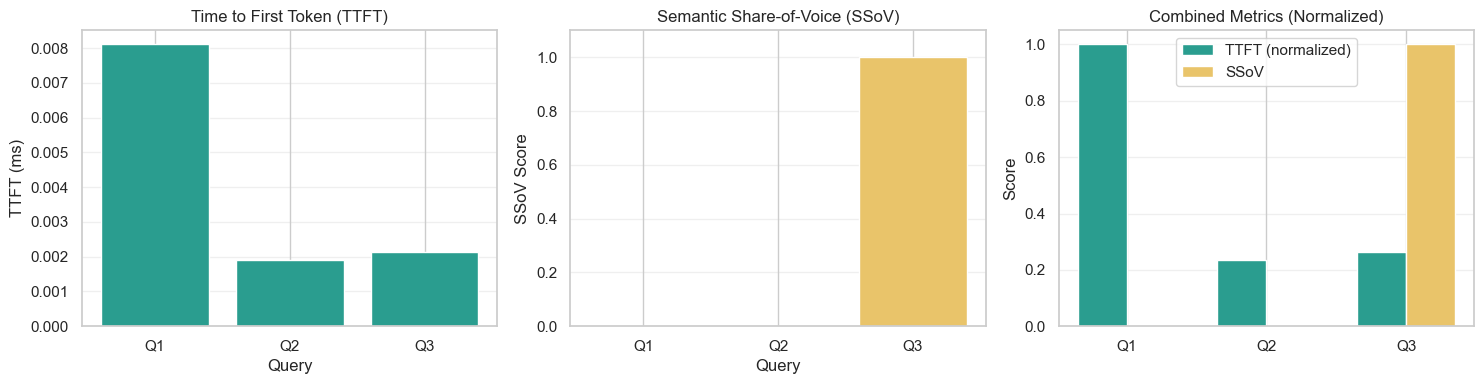


Average TTFT: 0.00 ms
Average SSoV: 0.33


In [8]:
# --- 3. VISUALIZE TTFT & SSoV ---
labels = [f"Q{i+1}" for i in range(len(results))]
ttft_vals = [r["ttft"] for r in results]
ssov_vals = [r["ssov"] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# TTFT bar chart
axes[0].bar(labels, ttft_vals, color="#2a9d8f")
axes[0].set_title("Time to First Token (TTFT)")
axes[0].set_xlabel("Query")
axes[0].set_ylabel("TTFT (ms)")
axes[0].grid(axis='y', alpha=0.3)

# SSoV bar chart
axes[1].bar(labels, ssov_vals, color="#e9c46a")
axes[1].set_title("Semantic Share-of-Voice (SSoV)")
axes[1].set_xlabel("Query")
axes[1].set_ylabel("SSoV Score")
axes[1].set_ylim(0, 1.1)
axes[1].grid(axis='y', alpha=0.3)

# Combined view
x = np.arange(len(labels))
width = 0.35
axes[2].bar(x - width/2, [t/max(ttft_vals) for t in ttft_vals], width, label="TTFT (normalized)", color="#2a9d8f")
axes[2].bar(x + width/2, ssov_vals, width, label="SSoV", color="#e9c46a")
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels)
axes[2].set_title("Combined Metrics (Normalized)")
axes[2].set_ylabel("Score")
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nAverage TTFT: {np.mean(ttft_vals):.2f} ms")
print(f"Average SSoV: {np.mean(ssov_vals):.2f}")

## Reranker Confidence Visualization
Visualize reranking scores for retrieved chunks.

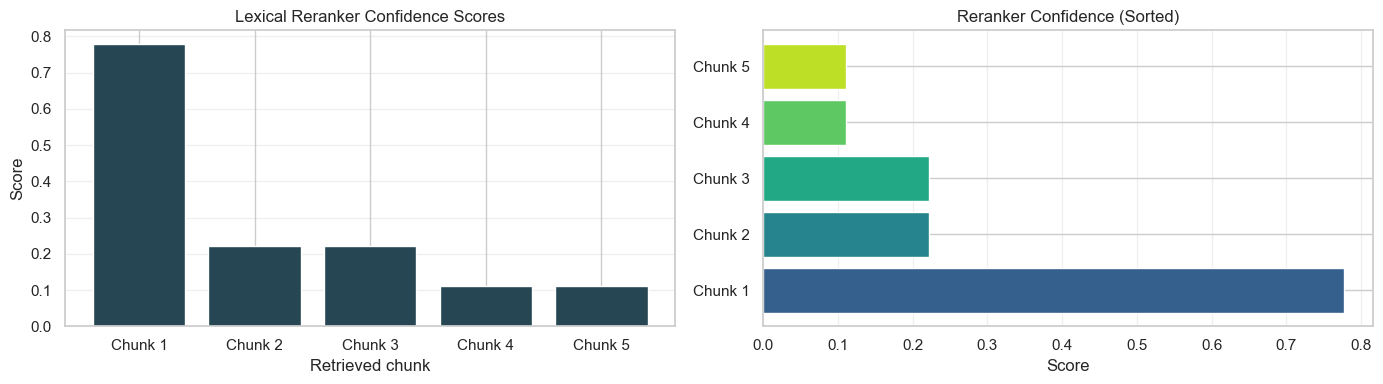


Top scoring chunk (score=0.778):
  Total Revenue for the fiscal year 2021 was reported at $10.0 Billion....


In [9]:
# --- 4. VISUALIZE RERANK CONFIDENCE ---
_, scored_docs = actual_hybrid_retrieve(test_cases[0]["query"], top_k=5, return_scores=True)
scores = [float(score) for _, score in scored_docs[:5]]
chunk_labels = [f"Chunk {i+1}" for i in range(len(scores))]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar plot
axes[0].bar(chunk_labels, scores, color="#264653")
axes[0].set_title("Lexical Reranker Confidence Scores")
axes[0].set_xlabel("Retrieved chunk")
axes[0].set_ylabel("Score")
axes[0].grid(axis='y', alpha=0.3)

# Horizontal bar with gradient
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(scores)))
axes[1].barh(chunk_labels, scores, color=colors)
axes[1].set_title("Reranker Confidence (Sorted)")
axes[1].set_xlabel("Score")
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTop scoring chunk (score={scores[0]:.3f}):")
print(f"  {scored_docs[0][0].page_content[:100]}...")

## Retrieval Quality Visualization
Visualize token overlap between each query and its retrieved context to diagnose retrieval relevance.

In [ ]:
# Retrieval Quality Visualization
if results:
    overlaps = []
    query_labels = []
    for i, case in enumerate(test_cases):
        context = actual_hybrid_retrieve(case["query"])
        context_text = "\n".join(context) if isinstance(context, list) else context
        q_tokens = set(case["query"].lower().split())
        c_tokens = set(context_text.lower().split())
        overlap = len(q_tokens & c_tokens) / max(1, len(q_tokens))
        overlaps.append(overlap)
        query_labels.append(f"Q{i+1}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].bar(query_labels, overlaps, color="#457b9d")
    axes[0].set_ylim(0, 1)
    axes[0].set_title("Query-Context Token Overlap Ratio")
    axes[0].set_xlabel("Query")
    axes[0].set_ylabel("Overlap ratio")
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].axhline(y=np.mean(overlaps), color='#e76f51', linestyle='--', linewidth=2, label=f'Mean: {np.mean(overlaps):.2f}')
    axes[0].legend()

    axes[1].imshow([overlaps], aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
    axes[1].set_xticks(range(len(query_labels)))
    axes[1].set_xticklabels(query_labels)
    axes[1].set_yticks([0])
    axes[1].set_yticklabels(['Overlap'])
    axes[1].set_title("Overlap Heatmap")

    for i, val in enumerate(overlaps):
        axes[1].text(i, 0, f"{val:.2f}", ha='center', va='center', color='black', fontweight='bold')

    plt.colorbar(axes[1].images[0], ax=axes[1], label='Overlap Score')
    plt.tight_layout()
    plt.show()

    print(f"\nAverage query-context overlap: {np.mean(overlaps):.3f}")
else:
    print("Skipping overlap visualization: no benchmark results available.")


## Next Steps

Continue to **Notebook 04 (Model Comparison & Ablation Studies)** for:
- Comparative model evaluation (fine-tuned vs baseline)
- Retrieval and generation ablation studies
- Multi-model architecture comparison

Then run **Notebook 05 (GEO Search Query)** and **Notebook 06 (Logical Reasoning Benchmark)** for specialized evaluations.